In [1]:
# Importing the required libraries
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the training features and target
X = pd.read_csv("../data/trainImage.csv")
y = pd.read_csv("../data/trainIndex.csv")
# Concatenating the training features and target into a single dataframe
df = pd.concat([X, y], axis=1)

In [3]:
df = df.drop(columns=["colId"])
print(df.columns)

Index(['pix1', 'pix2', 'pix3', 'pix4', 'pix5', 'pix6', 'pix7', 'pix8', 'pix9',
       'pix10',
       ...
       'pix776', 'pix777', 'pix778', 'pix779', 'pix780', 'pix781', 'pix782',
       'pix783', 'pix784', 'Index'],
      dtype='object', length=785)


In [4]:
# Renaming index col to target 
df.rename(columns={"Index":"target"}, inplace=True)
df.columns

Index(['pix1', 'pix2', 'pix3', 'pix4', 'pix5', 'pix6', 'pix7', 'pix8', 'pix9',
       'pix10',
       ...
       'pix776', 'pix777', 'pix778', 'pix779', 'pix780', 'pix781', 'pix782',
       'pix783', 'pix784', 'target'],
      dtype='object', length=785)

In [5]:
df.shape

(500, 785)

In [6]:
# Splitting the data into training and validation sets
X = df.drop('target', axis = 1)
y = df["target"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_val.shape)

(400, 784)
(100, 784)


In [7]:
# Fitting a baseline linear regression model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
# Predicting on the validation set
y_pred = model_lr.predict(X_val)

In [8]:
# Evaluating the prediction using r2 and mse
r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
print(f"R2 score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R2 score: -0.5600
Mean Squared Error: 0.2470


In [9]:
# Very Poor results from Linear Regression, trying Random Forest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_val)
# Evaluating RandomForest predictions
r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
print(f"R2 score:{r2:.4f}")
print(f"Mean Squared Error:{mse:.4f}")

R2 score:0.6461
Mean Squared Error:0.0560


In [10]:
# Trying lightgbm next
warnings.filterwarnings("ignore")
model_lgb = lgb.LGBMRegressor(verbose=-1, n_jobs=-1)
model_lgb.fit(X_train, y_train)
# Predciting and evaluating
y_pred = model_lgb.predict(X_val)
r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
print(f"R2 score:{r2:.4f}")
print(f"Mean Squared Error:{mse:.4f}")

R2 score:0.6960
Mean Squared Error:0.0481


In [11]:
models = {
    "Linear Regression" : model_lr,
    "Random Forest" : model_rf,
    "LightGBM" : model_lgb
}
for name, model in models.items():
    scores = cross_val_score(model, X, y, scoring="r2", cv=5)
    print(f"{name}:")
    print(f"Mean R Squared:{scores.mean():.4f}")
    print(f"Std R Squared:{scores.std():.4f}")

Linear Regression:
Mean R Squared:-0.4755
Std R Squared:0.3532
Random Forest:
Mean R Squared:0.6322
Std R Squared:0.0198
LightGBM:
Mean R Squared:0.7354
Std R Squared:0.0177


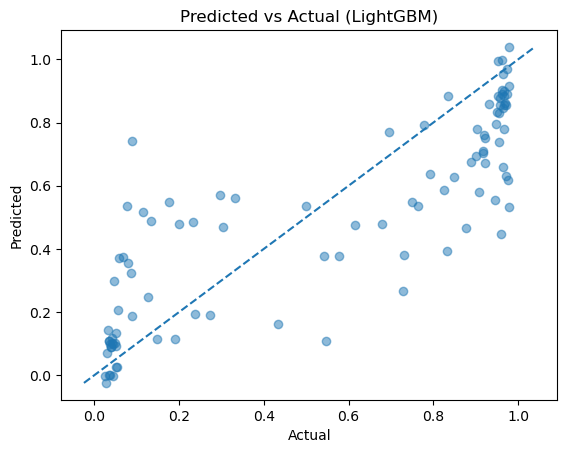

In [12]:
# Based on cross validation results, LightGBM is selected as the final model due to better performance (higher R2) and lower variance across folds

# Plotting actual values against predicted values from the lightgbm model
y_pred = model_lgb.predict(X_val)
plt.scatter(y_val, y_pred, alpha=0.5)
# Diagonal reference line
min_val = min(y_val.min(), y_pred.min())
max_val = max(y_val.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (LightGBM)")
plt.savefig("../figures/pred_vs_actual.png", dpi=300, bbox_inches='tight')
plt.show()

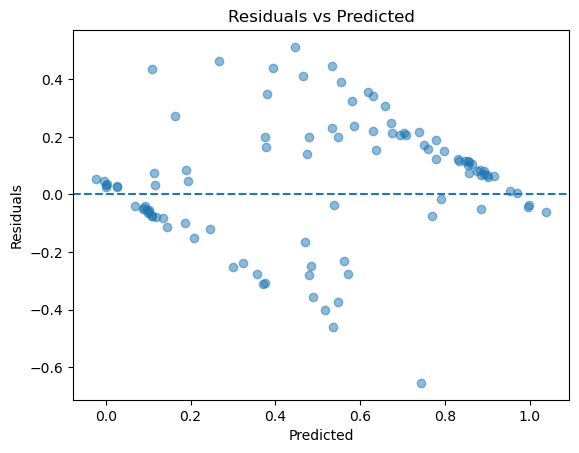

In [13]:
# Plotting the residuals of the lightgbm predictions against its predictions
residuals = y_val - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.savefig("../figures/residual_vs_predicted_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Error Analysis
results = pd.DataFrame({
    "actual": y_val,
    "predicted": y_pred,
    "residual": residuals
})
# Sorting worst predictions
worst = results.reindex(results["residual"].abs().sort_values(ascending=False).index)
worst.head(10)

,actual,predicted,residual
409,0.088534,0.742943,-0.654408
193,0.958919,0.446875,0.512045
86,0.729529,0.267370,0.462159
155,0.076299,0.535011,-0.458712
377,0.978019,0.532714,0.445305
362,0.832120,0.394533,0.437587
477,0.546832,0.109722,0.437111
22,0.876038,0.465815,0.410224
450,0.115224,0.516905,-0.401682
394,0.945066,0.555649,0.389418


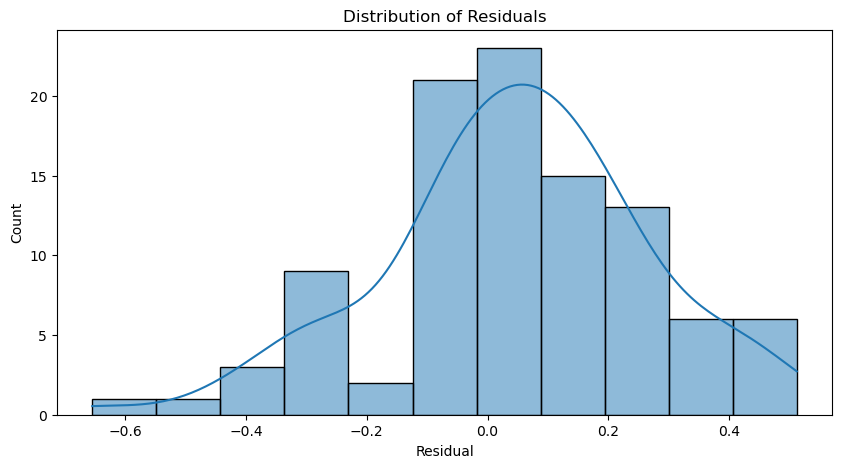

In [15]:
# Plotting distribution of residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

In [16]:
# Inspecting feature importances
importance = model_lgb.feature_importances_
features = X.columns
feat_imp = pd.DataFrame({
    "feature" : features,
    "importance" : importance
}).sort_values(by="importance", ascending=False)
feat_imp.head(10)

,feature,importance
600,pix601,15
660,pix661,14
323,pix324,14
234,pix235,13
57,pix58,13
545,pix546,12
446,pix447,11
573,pix574,11
625,pix626,11
261,pix262,10


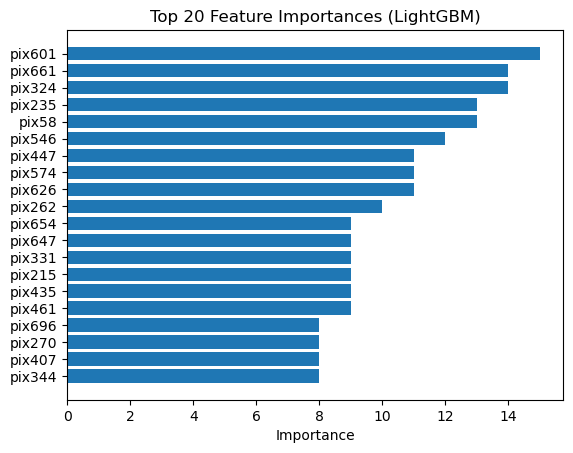

In [17]:
top20 = feat_imp.head(20)
plt.barh(top20["feature"], top20["importance"])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (LightGBM)")
plt.gca().invert_yaxis()
plt.savefig("../figures/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

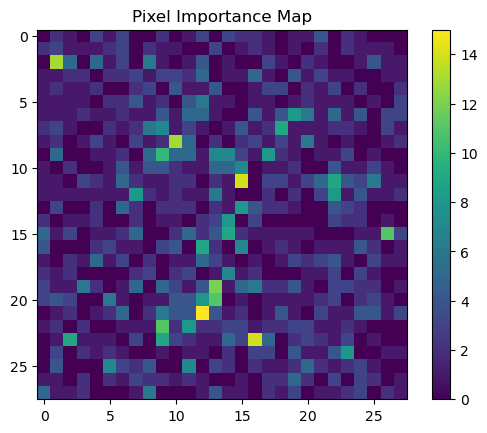

In [18]:
importance_array = feat_imp.set_index("feature").loc[X.columns]["importance"].values
importance_image = importance_array.reshape(28, 28)
plt.imshow(importance_image)
plt.title("Pixel Importance Map")
plt.colorbar()
plt.savefig("../figures/pixel_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Certain pixel regions contribute more strongly to predictions, suggesting localized spatial patterns in the data.
# Attemtping feature reduction to see if model needs all pixel info or if many pixels are redundant
top_features = feat_imp.head(50)["feature"]
X_reduced = X[top_features]
# Evaluating the lgb model on reduced features 
scores = cross_val_score(
    lgb.LGBMRegressor(verbose=-1, n_jobs=-1),
    X_reduced,
    y,
    scoring="r2",
    cv=5)
print("Reduced Features:")
print(f"Mean R Squared: {scores.mean():.4f}")
print(f"Std R Squared: {scores.std():.4f}")

Reduced Features:
Mean R Squared: 0.7639
Std R Squared: 0.0147


In [20]:
# Model performance improves upon reducing features to most important ones
# Experimenting to test optimal number of features
feature_sizes = [10, 25, 50, 100, 200]
results = []
for k in feature_sizes:
    top_k = feat_imp.head(k)["feature"]
    X_k = X[top_k]
    scores = cross_val_score(
        lgb.LGBMRegressor(verbose=-1, n_jobs=-1),
        X_k,
        y,
        scoring="r2",
        cv=5
    )
    results.append((k, scores.mean(), scores.std()))
for r in results:
    print(f"Top {r[0]} features: Mean R Squared: {r[1]:.4f}, Std: {r[2]:.4f}")

Top 10 features: Mean R Squared: 0.6511, Std: 0.0593
Top 25 features: Mean R Squared: 0.7169, Std: 0.0182
Top 50 features: Mean R Squared: 0.7639, Std: 0.0147
Top 100 features: Mean R Squared: 0.7741, Std: 0.0218
Top 200 features: Mean R Squared: 0.7618, Std: 0.0223


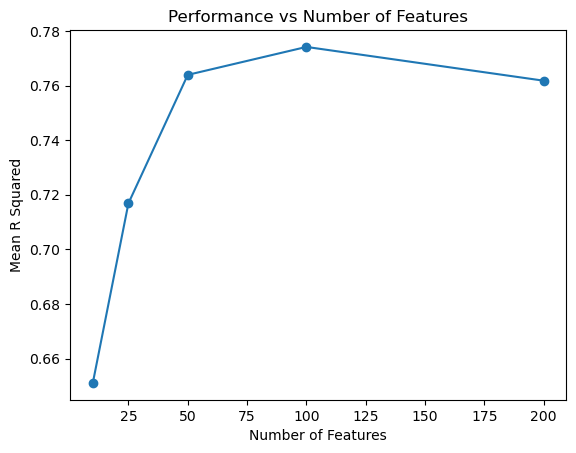

In [21]:
ks = [r[0] for r in results]
means = [r[1] for r in results]
plt.plot(ks, means, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Mean R Squared")
plt.title("Performance vs Number of Features")
plt.show()

In [24]:
# Model performance peaks at num imp features=100
top_features = feat_imp.head(100)["feature"]
X_reduced = X[top_features]
# Finetuning the model hyperparameters using randomized search on the reduced training set
param_grid = {
    "n_estimators": [100, 400, 500],
    "learning_rate": [0.03, 0.05, 0.7],
    "num_leaves": [30, 40, 60],
    "max_depth": [-1, 5, 10]
}
search = RandomizedSearchCV(
    lgb.LGBMRegressor(verbose=-1, n_jobs=-1),
    param_grid,
    n_iter=10,
    scoring="r2",
    cv=5,
    random_state=42
)
search.fit(X_reduced, y)
print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

Best params: {'num_leaves': 30, 'n_estimators': 400, 'max_depth': -1, 'learning_rate': 0.05}
Best CV score: 0.7813966317735362


In [25]:
# Saving the optimized hyperparameters
best_model = search.best_estimator_
# Loading the test set
test = pd.read_csv("../data/testImage.csv")
test_ids = test["colId"]
test = test.drop(columns=["colId"])
# Applying the same feature selection
test_reduced = test[top_features]
# Train, this time on FULL training data
best_model.fit(X_reduced, y)
# Final predictions
test_preds = best_model.predict(test_reduced)
submission = pd.DataFrame({
    "colID" : test_ids,
    "Expected" : test_preds
})
submission.to_csv('../results/submission.csv', index=False)